In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import glob

In [8]:
#load scores as df
beacon_scores = pd.read_csv('/Users/cherylxiang/Documents/GitHub/demultiplexing-methods/analysis/beacon_analysis/beacon_scores.csv')
dm2_scores = pd.read_csv('/Users/cherylxiang/Documents/GitHub/demultiplexing-methods/analysis/beacon_analysis/dm2_scores.csv')

In [9]:
#beacon scores
beacon_scores

,dataset,method,f1_micro,f1_macro,f1_weighted,mcc,concordance
0,mcginnis_ms,beacon,0.973107,0.954255,0.974594,0.969110,0.972688
1,mcginnis_ab,beacon,0.894140,0.834335,0.897149,0.877087,0.890968
2,bar11,beacon,0.769610,0.748964,0.772600,0.731767,0.750841
3,gaublomme,beacon,0.916667,0.869843,0.898140,0.907186,0.916667
4,howitt_capture1,beacon,0.817707,0.787506,0.826585,0.746861,0.816303
5,howitt_capture2,beacon,0.854008,0.806917,0.864854,0.792960,0.852605
6,howitt_capture3,beacon,0.864146,0.801886,0.870508,0.804697,0.862713
7,howitt_batch1_c1,beacon,0.911737,0.903108,0.917913,0.900386,0.911737
8,howitt_batch1_c2,beacon,0.896136,0.896345,0.900209,0.882711,0.896100
9,howitt_batch2_c1,beacon,0.833118,0.837336,0.845731,0.806028,0.831870


In [10]:
#dm2 scores
dm2_scores

,dataset,method,f1_micro,f1_macro,f1_weighted,mcc,concordance
0,mcginnis_ms,demultiplex2,0.948765,0.927126,0.957778,0.940097,0.945806
1,mcginnis_ab,demultiplex2,0.794185,0.761676,0.810383,0.732950,0.746022
2,bar11,demultiplex2,0.743077,0.726542,0.751658,0.652834,0.651129
3,gaublomme,demultiplex2,0.920096,0.871672,0.899732,0.909330,0.918262
4,howitt_capture1,demultiplex2,0.825766,0.791062,0.831525,0.749815,0.817930
5,howitt_capture2,demultiplex2,0.844707,0.761011,0.841656,0.768898,0.836380
6,howitt_capture3,demultiplex2,0.856202,0.745418,0.844850,0.778096,0.845045
7,howitt_batch1_c1,demultiplex2,0.866025,0.874596,0.891656,0.852351,0.862510
8,howitt_batch1_c2,demultiplex2,0.854152,0.871024,0.875798,0.835702,0.847666
9,howitt_batch2_c1,demultiplex2,0.102097,0.061841,0.065467,0.108180,0.099480


In [11]:
#beacon scores - dm2 scores
merged_beacon_dm2 = beacon_scores.merge(dm2_scores, on='dataset', suffixes=('_beacon', '_dm2'))

for metric in ['f1_micro', 'f1_macro', 'f1_weighted', 'mcc', 'concordance']:
    merged_beacon_dm2[f'{metric}_diff'] = merged_beacon_dm2[f'{metric}_beacon'] - merged_beacon_dm2[f'{metric}_dm2']

diff_cols = ['dataset'] + [f'{m}_diff' for m in ['f1_micro', 'f1_macro', 'f1_weighted', 'mcc', 'concordance']]

print('Difference in scores (Beacon - Demultiplex2)')
merged_beacon_dm2[diff_cols]

Difference in scores (Beacon - Demultiplex2)


,dataset,f1_micro_diff,f1_macro_diff,f1_weighted_diff,mcc_diff,concordance_diff
0,mcginnis_ms,0.024342,0.027129,0.016815,0.029014,0.026882
1,mcginnis_ab,0.099956,0.072659,0.086766,0.144137,0.144946
2,bar11,0.026533,0.022423,0.020942,0.078933,0.099712
3,gaublomme,-0.003429,-0.001829,-0.001593,-0.002144,-0.001595
4,howitt_capture1,-0.008058,-0.003556,-0.004941,-0.002954,-0.001627
5,howitt_capture2,0.009301,0.045907,0.023198,0.024062,0.016225
6,howitt_capture3,0.007944,0.056468,0.025658,0.026601,0.017669
7,howitt_batch1_c1,0.045712,0.028513,0.026257,0.048035,0.049227
8,howitt_batch1_c2,0.041984,0.025321,0.024411,0.047009,0.048434
9,howitt_batch2_c1,0.731021,0.775494,0.780265,0.697848,0.732390


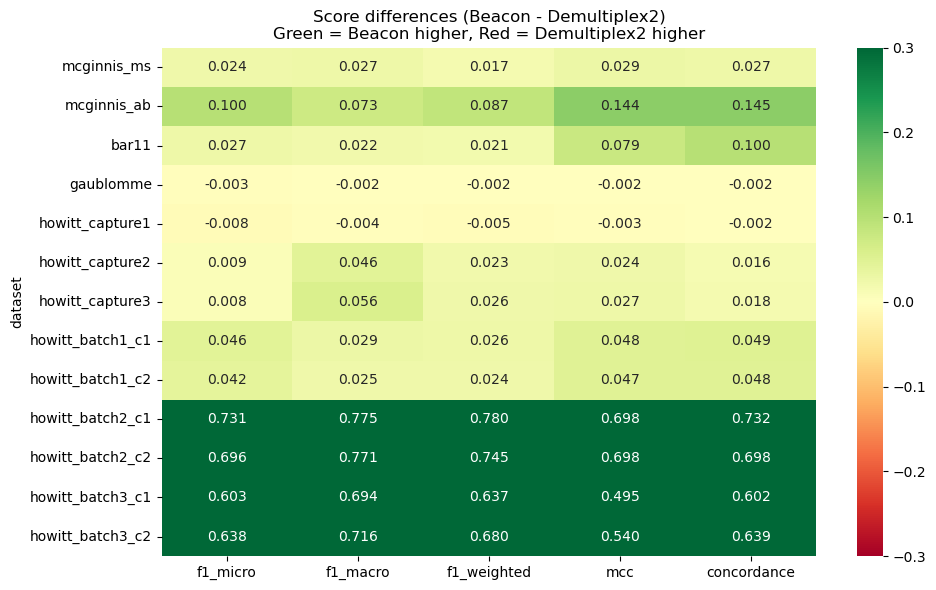

In [12]:
metrics = ['f1_micro', 'f1_macro', 'f1_weighted', 'mcc', 'concordance']
datasets = merged_beacon_dm2['dataset'].tolist()

diff_data = merged_beacon_dm2.set_index('dataset')[[f'{m}_diff' for m in metrics]]
diff_data.columns = metrics

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(diff_data, annot=True, fmt='.3f', 
            cmap='RdYlGn',  # red = dm2 better, green = beacon better
            center=0,
            vmin=-0.3, vmax=0.3,
            ax=ax)
ax.set_title('Score differences (Beacon - Demultiplex2)\nGreen = Beacon higher, Red = Demultiplex2 higher')
plt.tight_layout()
plt.show()

